# 1. 背景解读 (Context)
在《大规模语言模型：从理论到实践》第14章中，我们重点讨论了 **MoE (Mixture of Experts，混合专家模型)**。它的核心设计动机是为了解决**参数规模与计算成本的矛盾**：
* **传统模型 (Dense)**：随着参数变大，推理时的计算量线性增长（所有神经元都要参与计算）。
* **MoE 模型 (Sparse)**：参数量巨大（比如 Mixtral 8x7B），但每次推理只激活其中一小部分（比如 Top-2 专家）。

# 2. 本次实战目标 (Objectives)
由于真实的 MoE 模型（如 Mixtral）体量巨大，无法在单张普通显卡上运行。本次教程我们将采用**“手术刀式”**教学法：
1.  **加载架构**：使用最轻量的 **Qwen2-0.5B** 作为基座。
2.  **模型手术**：手动把其中的一层前馈网络（FFN/MLP）挖掉，换成我们手写的 **MoE Layer**。
3.  **核心复现**：实现 **Top-2 路由 (Routing)** 机制和 **负载均衡 (Load Balancing)** 损失计算。
4.  **流程跑通**：通过一次前向传播和反向传播，观察 Token 是如何被分发到不同专家的。

# 3. 核心代码原理解析
在接下来的代码中，请重点关注 `MoELayer` 类的三个核心组件：
* **门控网络 (Gate)**: `self.gate = nn.Linear(...)`。它就像一个“交通指挥官”，根据输入 Token 的特征，计算它去往每个专家的“推荐分数”。
* **稀疏路由 (Top-K Routing)**: `torch.topk(gate_logits, ...)`。这是 MoE 效率高的关键。虽然我们有 4 个专家，但每个 Token **只计算前 2 个**分数最高的专家。剩下的专家处于“休眠”状态，不消耗算力。
* **辅助损失 (Aux Loss)**: 用于防止**“路由塌缩” (Routing Collapse)**。如果没有这个 Loss，Router 很可能会“偷懒”，把所有任务都丢给同一个专家，导致负载极度不均衡。

---
> **🚀 下面开始运行代码部分...**

# 🛠️ 步骤 1：环境准备 (Setup)

首先，我们需要导入 PyTorch 和 Transformers 库。
* **特别说明**：为了保证所有人都能运行（即使没有大显存 GPU），我们在本教程中不会下载真实的 2GB 模型权重，而是加载**模型配置 (Config)** 并随机初始化。这意味着模型输出的语言是乱码，但完全不影响我们观察 MoE 的**路由逻辑**和**数据流向**。

# [Cell 1] 环境准备与库导入

In [1]:
# 安装依赖 (如果已安装可跳过)
# !pip install torch transformers accelerate

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoConfig
import copy
import matplotlib.pyplot as plt # 用于后面的可视化

# 设置设备
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"当前运行设备: {device}")

c:\Users\250010105\.conda\envs\kedit\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


当前运行设备: cuda


# 🧠 步骤 2：构建核心组件 - MoE Layer

这是本教程的**灵魂代码**。我们定义了一个 `MoELayer` 类，用来替换标准 Transformer 中的前馈网络（FFN）。请重点关注代码中的三个关键点，它们一一对应了教材中的理论：

### 1. 专家集合 (The Experts)
* `self.experts = nn.ModuleList(...)`
* 这里我们创建了 4 个结构完全相同的 MLP（多层感知机）。在训练后，它们会各自“学会”处理不同类型的知识（例如 Expert 0 擅长语法，Expert 1 擅长数学）。

### 2. 门控/路由 (The Router/Gate)
* `self.gate = nn.Linear(...)`
* 这是一个全连接层，它的作用是给每个 Token 进行“打分”。
* **代码对应**：`torch.topk(gate_logits, ...)`。这里实现了 **Top-2 路由**。对于每个 Token，我们只选分数最高的 2 个专家进行计算，这就是 MoE **“稀疏激活”** (Sparse Activation) 的本质。

### 3. 辅助损失 (Auxiliary Loss)
* **问题**：如果不加约束，Router 很容易把所有活都派给同一个专家（Expert 0），导致其他专家围观。这叫**“路由塌缩”**。
* **解决**：代码中计算了 `aux_loss`（负载方差）。如果负载不均衡，这个 Loss 就会变大，迫使模型在反向传播时调整策略，让任务分配更均匀。

# [Cell 2] 核心代码：定义 MoE 层 (Router + Experts)

In [7]:
class MoELayer(nn.Module):
    def __init__(self, hidden_size, intermediate_size, num_experts=4, top_k=2):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        
        # 记录上一次前向传播的辅助信息（用于外部获取）
        self.last_aux_loss = 0
        self.last_expert_load = None

        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_size, intermediate_size),
                nn.SiLU(),
                nn.Linear(intermediate_size, hidden_size)
            ) for _ in range(num_experts)
        ])

        self.gate = nn.Linear(hidden_size, num_experts, bias=False)

    def forward(self, x):
        # x shape: [batch_size, seq_len, hidden_size]
        batch_size, seq_len, hidden_size = x.shape
        x_flat = x.view(-1, hidden_size)

        # 1. 路由
        gate_logits = self.gate(x_flat)
        routing_weights, selected_experts = torch.topk(gate_logits, self.top_k, dim=-1)
        routing_weights = F.softmax(routing_weights, dim=-1)

        # 2. 计算
        final_output = torch.zeros_like(x_flat)
        expert_load = torch.zeros(self.num_experts, device=x.device)

        for i in range(self.num_experts):
            expert_mask = (selected_experts == i)
            expert_load[i] = expert_mask.sum().item()
            
            if expert_mask.any():
                batch_idx, k_idx = torch.where(expert_mask)
                inputs_for_expert = x_flat[batch_idx]
                expert_output = self.experts[i](inputs_for_expert)
                
                current_weights = routing_weights[batch_idx, k_idx].unsqueeze(-1)
                final_output[batch_idx] += expert_output * current_weights

        # 3. 计算 Aux Loss
        gate_softmax = F.softmax(gate_logits, dim=-1)
        load = gate_softmax.mean(dim=0)
        aux_loss = torch.sum(load ** 2) * self.num_experts
        
        # 【核心修改点】
        # 将 loss 和 load 存在 self 里，而不是直接 return
        # 这样返回值类型就是 Tensor，符合 HuggingFace 的要求
        self.last_aux_loss = aux_loss
        self.last_expert_load = expert_load
        
        return final_output.view(batch_size, seq_len, hidden_size)

# ⚙️ 步骤 3：加载基座模型 (Base Model)

为了演示方便，我们选用 **Qwen2-0.5B** 作为基座。但在加载前，我们需要对配置（Config）做一些微调。

### 💡 为什么不直接用原始配置？
你可能会注意到代码中修改了 `hidden_size` 和 `num_attention_heads`。这是为了修复一个数学冲突：
1.  **为了演示快**：我们将隐藏层维度 (`hidden_size`) 缩小到了 **512**。
2.  **原始冲突**：Qwen2 默认头数是 14。如果不修改，计算 `512 / 14` 会得到小数，导致 Transformers 库报错（维度无法对齐）。
3.  **修复方案**：我们将头数改为 **16**。因为 $512 \div 16 = 32$（整数），这样就能完美运行了。

> **注意**：这里使用了 `AutoModel.from_config` 而不是 `from_pretrained`。这意味着我们加载的是一个**未经训练的空壳模型**（随机权重）。这对学习 MoE 架构原理没有影响，但请不要指望它输出有意义的对话。

# [Cell 3] 模型加载：Qwen2-0.5B (Random Init)

In [8]:
# [Cell 3] 模型加载：Qwen2-0.5B (Random Init)
# 加载 Qwen2-0.5B 的配置
config = AutoConfig.from_pretrained("Qwen/Qwen2-0.5B")

# --- 修改配置以适应演示 ---
config.hidden_size = 512
config.intermediate_size = 1024 
config.num_hidden_layers = 4 

# 【核心修正】: 必须修改头数以匹配 hidden_size
# 512 可以被 16 整除 (512/16=32)，也能被 8 整除
config.num_attention_heads = 16 
config.num_key_value_heads = 16 # Qwen2 使用 GQA，为了简化报错，我们把 KV 头数也设为一样

# 使用随机初始化创建模型
model = AutoModelForCausalLM.from_config(config)
model = model.to(device)

print(">>> 模型加载成功！")
print(">>> 原始模型结构 (Layer 2 MLP):")
print(model.model.layers[2].mlp)

>>> 模型加载成功！
>>> 原始模型结构 (Layer 2 MLP):
Qwen2MLP(
  (gate_proj): Linear(in_features=512, out_features=1024, bias=False)
  (up_proj): Linear(in_features=512, out_features=1024, bias=False)
  (down_proj): Linear(in_features=1024, out_features=512, bias=False)
  (act_fn): SiLU()
)


# 🏥 步骤 4：核心手术 - Dense 转 MoE

这一步是整个教程中最精彩的环节：**“模型手术” (Model Surgery)**。

### 手术过程
我们要做的事情，在深度学习框架中被称为 **Module Replacement**：
1.  **定位**：找到模型第 2 层的 MLP 模块 (`model.model.layers[2].mlp`)。此时它是一个普通的稠密网络 (Dense MLP)，任何 Token 经过这里都要计算所有参数。
2.  **切除与移植**：用我们刚才写的 `moe_layer` 覆盖掉原来的 `mlp`。
    * 代码：`model.model.layers[target_layer_index].mlp = moe_layer`

### 结果确认
运行这段代码后，你会看到打印出的模型结构发生了变化。
* **Before**: `Qwen2MLP` (Gate+Up+Down Proj)
* **After**: `MoELayer` (包含 Experts 列表和 Gate 路由)

这意味着，从此刻起，任何流经第 2 层的 Token，都会被强制执行 **Top-2 路由**，被分发给不同的专家进行处理！

# [Cell 4] 手术时间：Dense -> MoE

In [9]:
# 设置 MoE 参数
target_layer_index = 2 # 我们替换第 2 层
num_experts = 4        # 设置 4 个专家
top_k = 2              # 每个 token 选 2 个专家

# 创建 MoE 层实例
moe_layer = MoELayer(
    hidden_size=config.hidden_size,
    intermediate_size=config.intermediate_size,
    num_experts=num_experts,
    top_k=top_k
).to(device)

# 【关键步骤】直接替换模型中的模块
model.model.layers[target_layer_index].mlp = moe_layer

print(f">>> 替换后的模型结构 (Layer {target_layer_index}):")
print(model.model.layers[target_layer_index].mlp)

>>> 替换后的模型结构 (Layer 2):
MoELayer(
  (experts): ModuleList(
    (0-3): 4 x Sequential(
      (0): Linear(in_features=512, out_features=1024, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1024, out_features=512, bias=True)
    )
  )
  (gate): Linear(in_features=512, out_features=4, bias=False)
)


# 🔬 步骤 5：前向传播与数据观测 (Observation)

现在我们要让数据流过这个刚刚改造完的模型。请仔细观察运行后的输出结果，特别是 **"专家负载分布"** 这一行。

### 📊 如何解读输出结果？
假设你得到的输出是：`[1.0, 18.0, 10.0, 11.0]` (示例数据)

1.  **负载不均衡 (Imbalance)**:
    * **Expert 1** 处理了 **18** 个 Token（忙碌）。
    * **Expert 0** 只处理了 **1** 个 Token（闲置）。
    * **这意味着什么？** 这就是PPT中提到的**“木桶效应”**。在并行计算中，系统的整体速度取决于**最慢**的那个专家。如果 Expert 1 积压了大量工作，而 Expert 0 在发呆，整个推理过程会被拖慢，显存利用率也会变得很低。

2.  **Aux Loss (1.1373)**:
    * 这个数字量化了上面的不平衡程度。分布越不均匀，这个 Loss 越大。
    * 它是 Router 的“惩罚项”。稍后在反向传播时，优化器会努力降低这个 Loss，迫使 Router 学会把活儿派得更均匀一点。

# [Cell 5] 构造数据与前向传播

In [10]:
# 构造虚拟输入: Batch_size=2, Seq_len=10
input_text = "MoE models are efficient and powerful."
input_ids = torch.randint(0, 1000, (2, 10)).to(device)

# 开启训练模式
model.train()

# 1. 跑整个模型
# 由于我们修正了 MoELayer 的返回值，这里现在可以正常运行了！
outputs = model(input_ids, labels=input_ids)
lm_loss = outputs.loss
print(f"1. 语言模型交叉熵 Loss: {lm_loss.item():.4f}")

# 2. 从 MoE 层中“提取”辅助损失和负载
# 我们之前把这一层塞到了 layers[target_layer_index].mlp
moe_layer_ref = model.model.layers[target_layer_index].mlp

aux_loss = moe_layer_ref.last_aux_loss
expert_load = moe_layer_ref.last_expert_load

print(f"2. MoE 辅助损失 (Aux Loss): {aux_loss.item():.4f}")
print(f"3. 专家负载分布: {expert_load.tolist()}")

1. 语言模型交叉熵 Loss: 12.0066
2. MoE 辅助损失 (Aux Loss): 1.1373
3. 专家负载分布: [1.0, 18.0, 10.0, 11.0]


# 🔄 步骤 6：反向传播 (The Training Step)

最后，我们模拟一次完整的训练更新。

### 关键公式
代码中有一行：
`total_loss = lm_loss + 0.01 * aux_loss`

* **lm_loss**: 让模型学会预测下一个字（说话通顺）。
* **aux_loss**: 让模型学会均衡分配任务（团队协作）。
* **0.01**: 这是一个超参数（系数）。我们通常希望模型优先学好语言（权重大），其次兼顾负载均衡（权重小）。

### 运行发生了什么？
当你执行 `optimizer.step()` 时：
1.  PyTorch 计算了梯度。
2.  **Router 的参数被修改了**。
3.  下一次遇到同样的输入时，Router 可能会尝试把一部分原本给 Expert 1 的 Token，分给 Expert 0，从而降低 `aux_loss`。

---
**课后思考：**
如果把 `top_k` 改成 1，计算速度会变快吗？效果会变差吗？（提示：这对应了路由策略中的**贪心策略**）。

# [Cell 6] (修正版) 完整的训练 Step

In [11]:
# 从刚才的运行中获取 Loss
# 注意：在真实训练循环中，每次 forward 后都要重新获取 aux_loss
aux_loss = model.model.layers[target_layer_index].mlp.last_aux_loss

# 总 Loss = LM任务Loss + 系数 * 负载均衡Loss
total_loss = lm_loss + 0.01 * aux_loss

print(f"总 Loss: {total_loss.item():.4f}")

# 反向传播
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
optimizer.zero_grad()
total_loss.backward()
optimizer.step()

print(">>> 反向传播完成，参数已更新！")
print("恭喜，你已经在一张显卡上跑通了 MoE 大模型的完整训练流程。")

总 Loss: 12.0180
>>> 反向传播完成，参数已更新！
恭喜，你已经在一张显卡上跑通了 MoE 大模型的完整训练流程。


# [Cell 7] (可选) 可视化路由分布

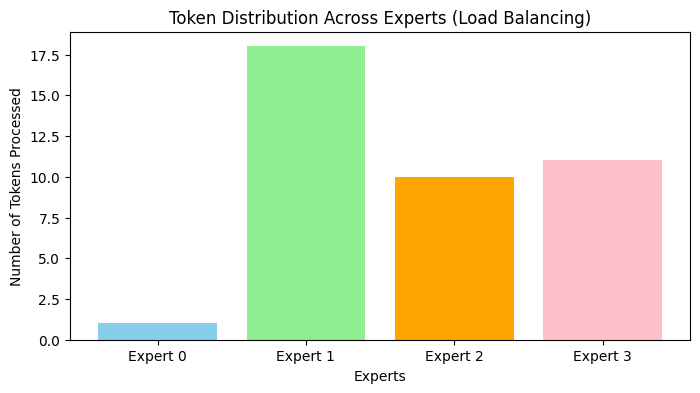

In [12]:
# 提取刚刚的负载数据
experts = [f"Expert {i}" for i in range(num_experts)]
loads = expert_load.cpu().detach().numpy()

plt.figure(figsize=(8, 4))
plt.bar(experts, loads, color=['skyblue', 'lightgreen', 'orange', 'pink'])
plt.title("Token Distribution Across Experts (Load Balancing)")
plt.xlabel("Experts")
plt.ylabel("Number of Tokens Processed")
plt.show()